## Large Dataset of Cars

- This dataset provides a comprehensive overview of various vehicles and their key technical specifications. It includes detailed attributes such as brand,  vehicle class, region of origin, engine size, horsepower, and fuel efficiency. Both MSRP and dealer cost are included, enabling analysis of pricing strategies and market positioning. With engine characteristics like horsepower, kagglers can explore performance comparisons between different car segments. The dataset also includes physical dimensions such as weight, wheelbase, and total length, useful for engineering or analysis. It is well-suited for building predictive models to estimate car prices or fuel consumption. Kagglers can use it to identify correlations between technical specifications and pricing. It is also valuable for clustering similar vehicles or segmenting the market based on car class and region. Whether you're passionate about cars, machine learning, or market analytics, this dataset offers a rich ground for experimentation. Ideal for projects in regression, classification, or data visualization.


## Columns:

- Brand – car brand
- VehicleClass – body type
- Region – geographical region where the car was manufactured
- MSRP – manufacturer’s suggested retail price
- DealerCost – the price at which the car is sold by the dealer
- EngineSize – size of the engine in liters
- HorsePower – maximum engine power output in horsepower
- MPG_City – fuel economy in miles per gallon while driving in city conditions
- MPG_Highway – fuel economy in miles per gallon while driving on highways
- Weight – weight of the vehicle in pounds
- Wheelbase – distance between the front and rear wheels
- Length – total length of the vehicle from bumper to bumper

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandasql as psql

In [7]:
df = pd.read_excel("Large Cars Dataset.xlsx")

In [8]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197
...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 428 entries, 0 to 427
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand         428 non-null    object 
 1   VehicleClass  428 non-null    object 
 2   Region        428 non-null    object 
 3   MSRP          428 non-null    int64  
 4   DealerCost    428 non-null    int64  
 5   EngineSize    428 non-null    float64
 6   HorsePower    428 non-null    int64  
 7   MPG_City      428 non-null    int64  
 8   MPG_Highway   428 non-null    int64  
 9   Weight        428 non-null    int64  
 10  Wheelbase     428 non-null    int64  
 11  Length        428 non-null    int64  
dtypes: float64(1), int64(8), object(3)
memory usage: 40.3+ KB


## Goals:

- Which brand is the most valuable?
- What is the most valuable vehicle class?
- Which region that makes the most valuable vehicles?
- What factors that contributes to a vehicle's value?
- What vehicle class is the most fuel-efficient?
- What is the lightest vehicle class?
- Which vehicle class that has the best performance?

In [12]:
df['Value'] = df['MSRP'] - df['DealerCost'] # Suggested retail price - dealer's cost

In [13]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## Goal 1: Which brand is the most valuable?

## 1)Market value of brand

In [16]:
query1 = """SELECT Brand, SUM(Value) as Value FROM df 
GROUP BY Brand"""

In [17]:
Brand = psql.sqldf(query1)

In [18]:
Brand

,Brand,Value
0,Acura,30434
1,Audi,75578
2,BMW,73292
3,Buick,24146
4,Cadillac,32380
5,Chevrolet,68208
6,Chrysler,29729
7,Dodge,27219
8,Ford,47446
9,GMC,26169


In [19]:
Brand_sort = Brand.sort_values(by = 'Value', ascending = False)

In [20]:
Brand_sort

,Brand,Value
23,Mercedes-Benz,109291
1,Audi,75578
2,BMW,73292
29,Porsche,69315
5,Chevrolet,68208
15,Jaguar,65784
35,Toyota,62399
19,Lexus,60010
8,Ford,47446
36,Volkswagen,38490


## 2)Value of brand

In [22]:
query2 = """SELECT Brand, AVG(Value) as Value FROM df 
GROUP BY Brand"""

In [23]:
Brand_value = psql.sqldf(query2)

In [24]:
Brand_value

,Brand,Value
0,Acura,4347.714286
1,Audi,3977.789474
2,BMW,3664.600000
3,Buick,2682.888889
4,Cadillac,4047.500000
5,Chevrolet,2526.222222
6,Chrysler,1981.933333
7,Dodge,2093.769231
8,Ford,2062.869565
9,GMC,3271.125000


In [25]:
Brand_value_sort = Brand_value.sort_values(by = 'Value', ascending = False)

In [26]:
Brand_value_sort

,Brand,Value
29,Porsche,9902.142857
15,Jaguar,5482.000000
19,Lexus,5455.454545
0,Acura,4347.714286
23,Mercedes-Benz,4203.500000
11,Hummer,4180.000000
4,Cadillac,4047.500000
18,Land Rover,3980.666667
1,Audi,3977.789474
20,Lincoln,3739.777778


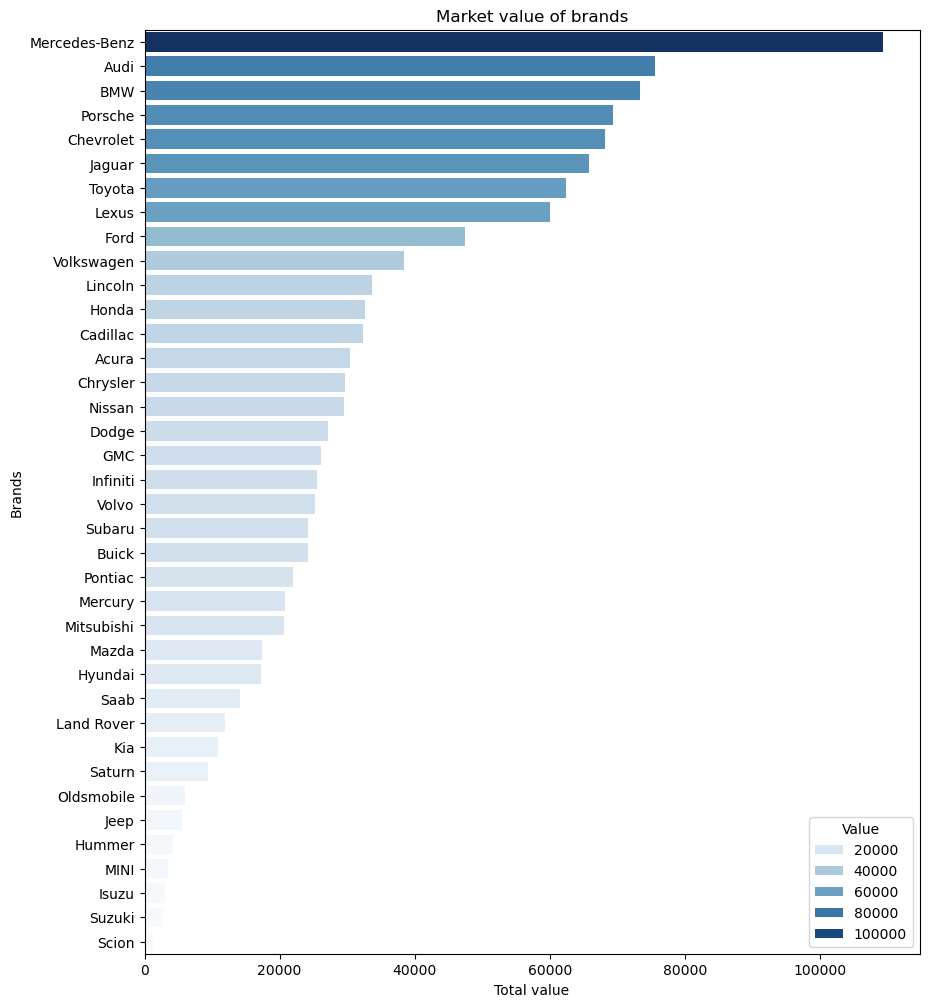

In [27]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Brand_sort, y = Brand_sort['Brand'], x = Brand_sort['Value'], palette = 'Blues', hue = Brand_sort['Value'])
plt.xlabel('Total value')
plt.ylabel('Brands')
plt.title('Market value of brands')
plt.show()

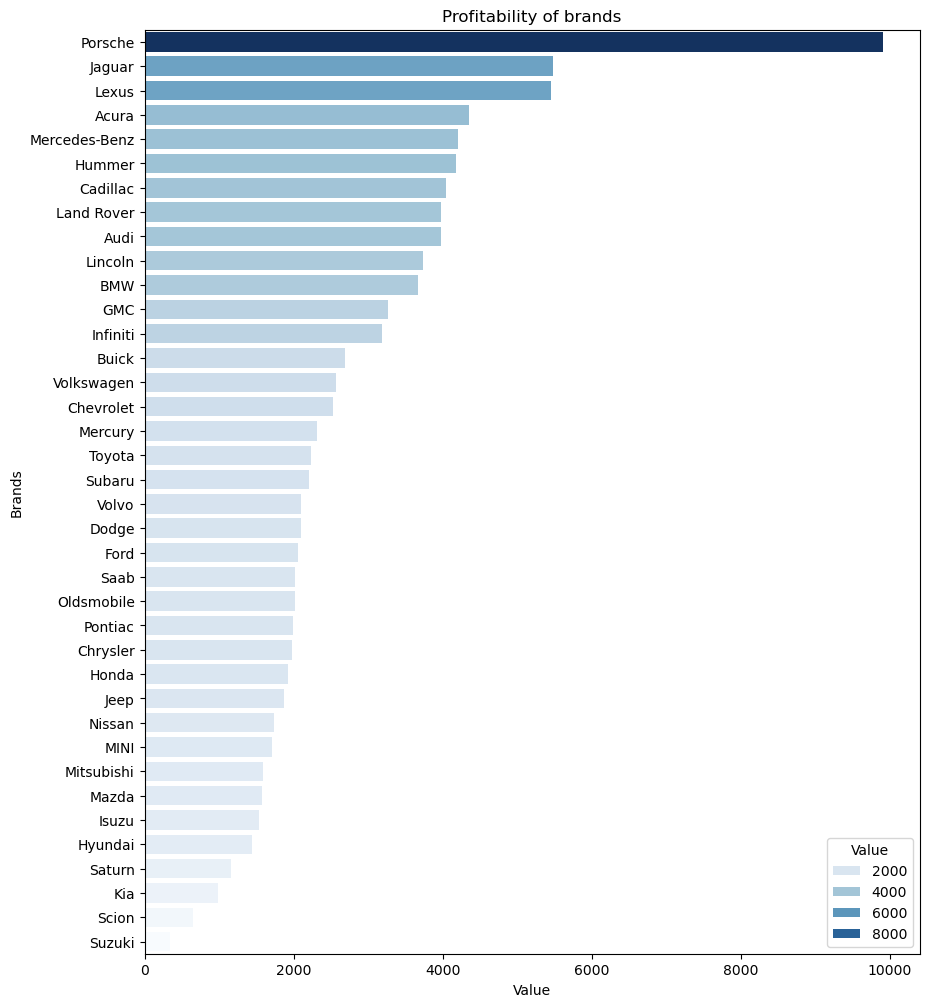

In [28]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Brand_value_sort, y = Brand_value_sort['Brand'], x = Brand_value_sort['Value'], palette = 'Blues', 
            hue = Brand_value_sort['Value'])
plt.xlabel('Value')
plt.ylabel('Brands')
plt.title('Profitability of brands')
plt.show()

## Conclusions:
- Mercedes-Benz, Audi, BMW, Porsche, Chevrolet, Jaguar, Toyota, Lexus and Ford are the brands with the highest market values.
- In contrast, Porsche has the highest brand recognition, followed by Jaguar and Lexus, meaning they make the most luxurious and valuable vehicles.

# Case studies:
## Porsche: 
- Known for its quality performance and valuable heritage, Same thing for both Jaguar and Lexus.
## Toyota:
- Suprisingly has slightly weak brand recognition, it makes profits from selling economic cars than luxurious cars.
## Hummer:
1) It has weak market value due to its struggle with practicality in every day activities, rising fuel prices and environmental criticism.
2) But has high brand recognition due to it being the first vehicle brand to make SUVS (Sport utility vehicles) and being marketed by different celebirties like Arnold Schwarzenegger.
## Ford:
- which is known for being one of the first vehicle brands to make cars affordable for everyone due to mass production, has suffered immense problems which weakened its brand recognition: Its focus on quantity over quality, its dependency on fuel which was skyrocketed after the 2008 financial crisis and the whole world decided to look for different energy sources to use in manufacturing of cars, Same thing for chervolet.
## Suzuki:
- Has the weakest market value and brand recognition, it focuses on the Japanese market and few other markets like the middle east.

## Goal 2: What is the most valuable vehicle class?

In [55]:
df

,Brand,VehicleClass,Region,MSRP,DealerCost,EngineSize,HorsePower,MPG_City,MPG_Highway,Weight,Wheelbase,Length,Value
0,Acura,SUV,Asia,36945,33337,3.5,265,17,23,4451,106,189,3608
1,Acura,Sedan,Asia,23820,21761,2.0,200,24,31,2778,101,172,2059
2,Acura,Sedan,Asia,26990,24647,2.4,200,22,29,3230,105,183,2343
3,Acura,Sedan,Asia,33195,30299,3.2,270,20,28,3575,108,186,2896
4,Acura,Sedan,Asia,43755,39014,3.5,225,18,24,3880,115,197,4741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
423,Volvo,Sedan,Europe,40565,38203,2.4,197,21,28,3450,105,186,2362
424,Volvo,Sedan,Europe,42565,40083,2.3,242,20,26,3450,105,186,2482
425,Volvo,Sedan,Europe,45210,42573,2.9,268,19,26,3653,110,190,2637
426,Volvo,Wagon,Europe,26135,24641,1.9,170,22,29,2822,101,180,1494


## 1) Market value of class

In [57]:
Total_class = df.groupby('VehicleClass')['Value'].sum().reset_index()

In [59]:
Total_class

,VehicleClass,Value
0,Hybrid,4472
1,SUV,189894
2,Sedan,624561
3,Sports,240781
4,Truck,55791
5,Wagon,65847


In [70]:
Total_class_sort = Total_class.sort_values(by = 'Value', ascending = False)

In [72]:
Total_class_sort

,VehicleClass,Value
2,Sedan,624561
3,Sports,240781
1,SUV,189894
5,Wagon,65847
4,Truck,55791
0,Hybrid,4472


## 2) Class by profitability

In [66]:
Avg_class = df.groupby('VehicleClass')['Value'].mean().reset_index()

In [68]:
Avg_class

,VehicleClass,Value
0,Hybrid,1490.666667
1,SUV,3164.900000
2,Sedan,2383.820611
3,Sports,4913.897959
4,Truck,2324.625000
5,Wagon,2194.900000


In [74]:
Avg_class_sort = Avg_class.sort_values(by = 'Value', ascending = False)

In [76]:
Avg_class_sort

,VehicleClass,Value
3,Sports,4913.897959
1,SUV,3164.900000
2,Sedan,2383.820611
4,Truck,2324.625000
5,Wagon,2194.900000
0,Hybrid,1490.666667


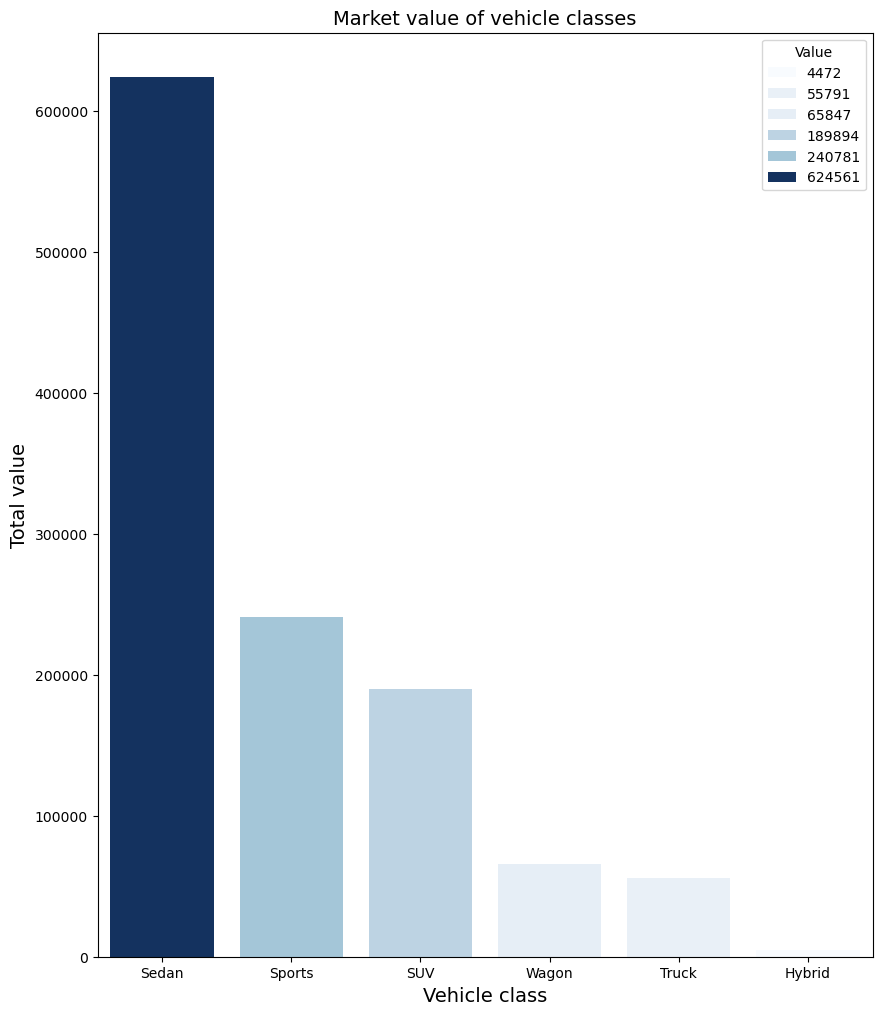

In [84]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Total_class_sort, x = Total_class_sort['VehicleClass'], y = Total_class_sort['Value'], palette = 'Blues', hue = Total_class_sort['Value'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Total value', size = 14)
plt.title('Market value of vehicle classes', size = 14)
plt.show()

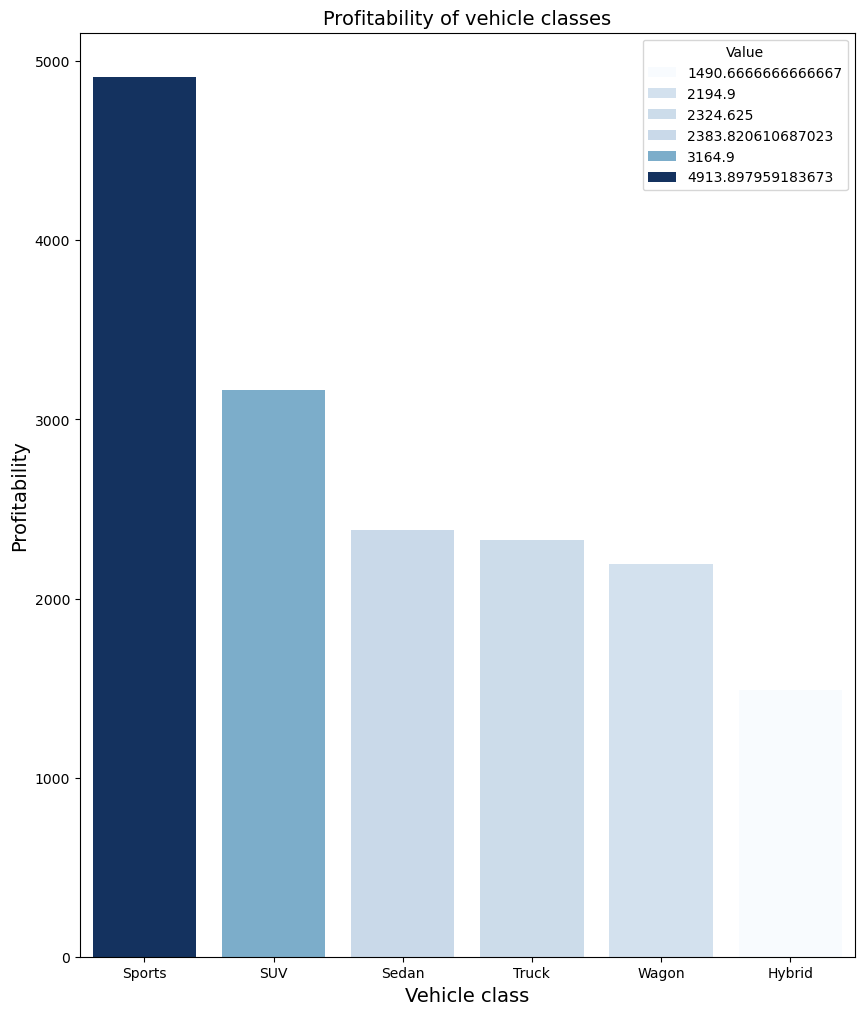

In [86]:
plt.figure(figsize= (10, 12))
sns.barplot(data = Avg_class_sort, x = Avg_class_sort['VehicleClass'], y = Avg_class_sort['Value'], palette = 'Blues', hue = Avg_class_sort['Value'])
plt.xlabel('Vehicle class', size = 14)
plt.ylabel('Profitability', size = 14)
plt.title('Profitability of vehicle classes', size = 14)
plt.show()

## Conclusions:
- Sedan vehicle class has the most market value due to the abundance of vehicles that belong to this class.
- But it's the least profitable.
- In contrast, Sports vehicle class is the most profitable, this class promotes luxury, brand awarness, impression and prestige.
- But it's less abundant due to its limited supply, which increases its demand and therefore its value.
- SUV vehicle class is profitable, it offers both luxury and practicality, they cater to everyday needs: from travels to work to comfort.
- But like sports vehicle class, it's less abundent.
- Truck, Wagon and Hybrid vehicle classes are the least abundant and the least profitable.
- This is due to them being function based rather than variety based.